Loading corpus...
Corpus size: 49954

Loading test set...
Test set size: 2000

TRAINING FORWARD-BACKWARD HMM
Training Forward-Backward HMM...
HMM trained: 24 positions

TRAINING Q-LEARNING AGENT WITH FB-HMM
Training for 12000 episodes...


  4%|▍         | 502/12000 [01:08<23:33,  8.13it/s]

Ep 500: Reward=77.71, Win=16.80%, Eps=0.704602


  8%|▊         | 1001/12000 [02:17<21:21,  8.58it/s]

Ep 1000: Reward=133.46, Win=24.80%, Eps=0.496464


...

Ep 11500: Reward=225.43, Win=38.40%, Eps=0.050000


100%|██████████| 12000/12000 [27:53<00:00,  7.17it/s]


Ep 12000: Reward=228.06, Win=39.80%, Eps=0.050000

Training complete. Final Q-Function Weights:
---------------------------------------------
           Bias: -11.456692
       HMM_Prob:  494.440472
       Is_Vowel:  15.359336
     Lives_Left:  239.945975
    Blanks_Left:  16.706193
 HMM_Prob*Vowel:  53.983627
---------------------------------------------

EVALUATING ON TEST SET


100%|██████████| 2000/2000 [02:18<00:00, 14.40it/s]



FINAL RESULTS - FORWARD-BACKWARD HMM + Q-LEARNING (Fn Approx)
Success Rate: 37.95% (759/2000)
Total Wrong Guesses: 10015
Avg Wrong/Game: 5.01
Final Score: -49316

✓ Plot saved as 'fb_hmm_q_func_approx_results.png'


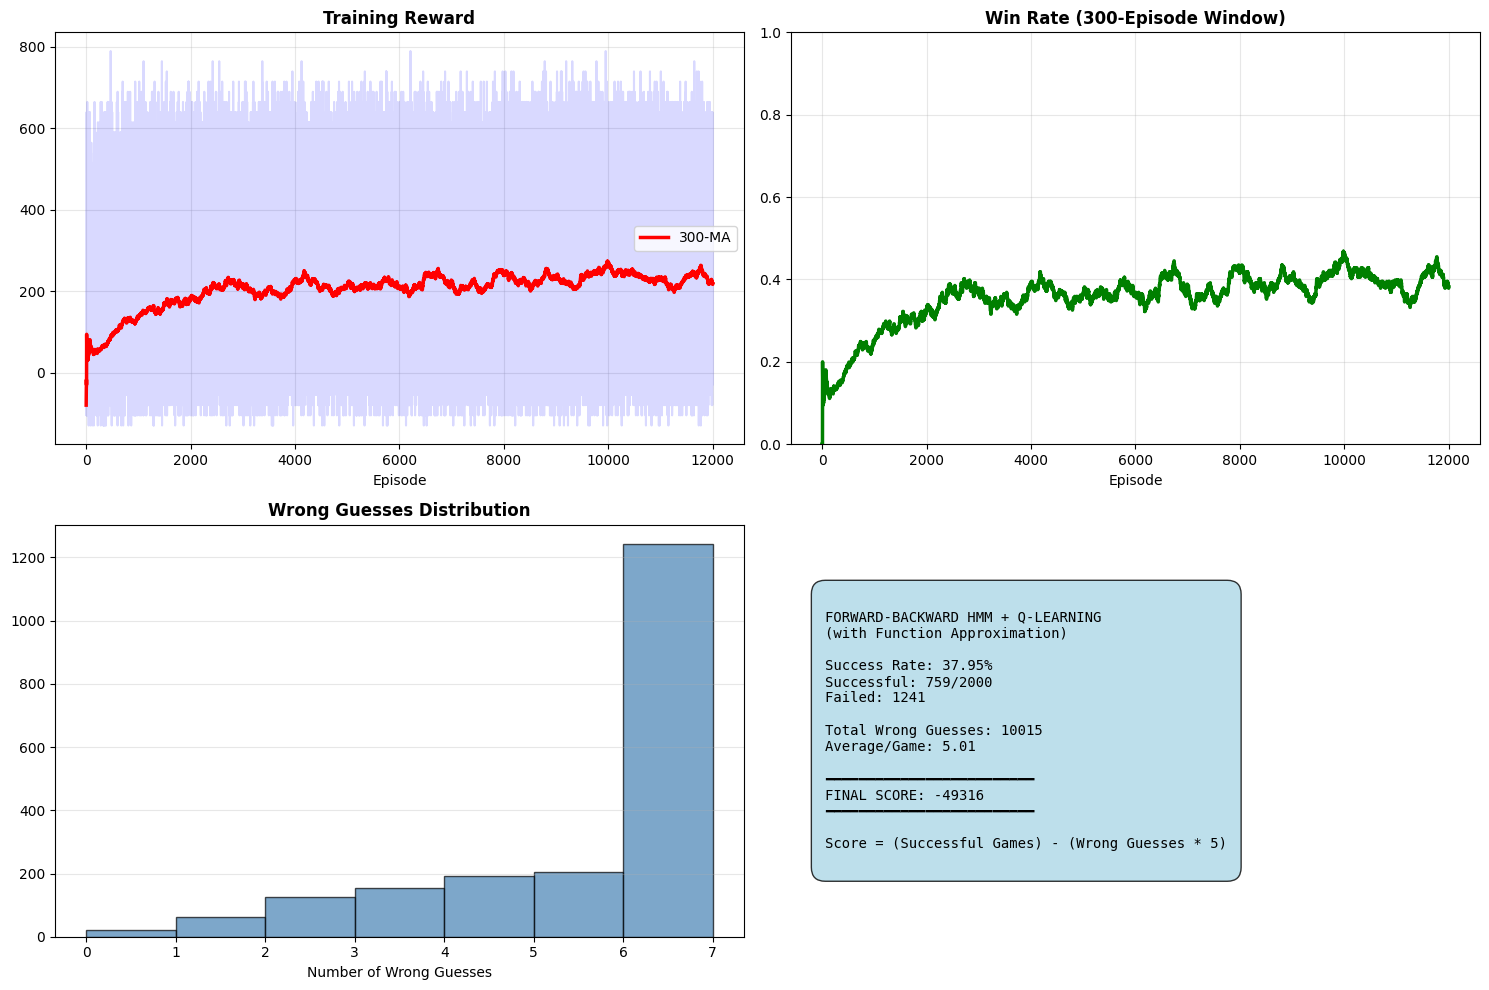


Training Complete!


In [ ]:
# ============================================================================
# HANGMAN WITH FORWARD-BACKWARD HMM + Q-LEARNING (FUNCTION APPROXIMATION)
# ============================================================================

import numpy as np
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PART 1: HMM WITH FORWARD-BACKWARD ALGORITHM
# ============================================================================

class ForwardBackwardHMM:
    """
    Hidden Markov Model with Forward-Backward algorithm for inference.

    Uses "hard" 0/1 emissions based on game rules for much
    stronger inference.
    """

    def __init__(self, max_word_len=25):
        self.max_word_len = max_word_len
        self.transition_probs = defaultdict(lambda: defaultdict(lambda: defaultdict(float)))
        self.state_priors = defaultdict(lambda: defaultdict(float))
        self.position_char_counts = defaultdict(lambda: Counter())
        self.position_totals = defaultdict(int)
        self.alphabet = set('abcdefghijklmnopqrstuvwxyz')

    def train(self, words):
        """Train HMM on corpus"""
        print("Training Forward-Backward HMM...")

        for word in words:
            word = word.lower()
            if len(word) > self.max_word_len or len(word) < 1:
                continue

            for pos, char in enumerate(word):
                if char.isalpha():
                    self.position_char_counts[pos][char] += 1
                    self.position_totals[pos] += 1

            for pos in range(len(word) - 1):
                char_i = word[pos]
                char_j = word[pos + 1]
                if char_i.isalpha() and char_j.isalpha():
                    self.transition_probs[pos][char_i][char_j] += 1

        # Normalize state priors with Laplace smoothing
        for pos in self.position_char_counts:
            total = self.position_totals[pos]
            for char in self.alphabet:
                count = self.position_char_counts[pos].get(char, 0)
                self.state_priors[pos][char] = (count + 1) / (total + 26)

        # Normalize transition probabilities
        for pos in self.transition_probs:
            for char_i in self.transition_probs[pos]:
                total = sum(self.transition_probs[pos][char_i].values())
                # Add-1 smoothing for all possible next characters
                for char_j in self.alphabet:
                    count = self.transition_probs[pos][char_i].get(char_j, 0)
                    self.transition_probs[pos][char_i][char_j] = (count + 1) / (total + 26)

        print(f"HMM trained: {len(self.position_char_counts)} positions")

    # CHANGED: Now takes guessed_letters for "hard" 0/1 emissions
    def get_emission_prob(self, observed, state_char, guessed_letters):
        """
        P(observed_letter | state_char)
        - This is a "hard" 0/1 probability based on Hangman rules.
        """
        # Case 1: The mask shows a specific letter (e.g., 'a')
        if observed != '_':
            if observed == state_char:
                return 1.0  # P(obs='a' | state='a') = 1.0
            else:
                return 0.0  # P(obs='a' | state='b') = 0.0

        # Case 2: The mask shows a blank ('_')
        else:
            # If the true letter (state_char) has already been guessed,
            # we would not be seeing a blank. This state is impossible.
            if state_char in guessed_letters:
                return 0.0 # P(obs='_' | state='a', 'a' in guessed) = 0.0

            # If the true letter has NOT been guessed,
            # then it is perfectly valid to observe a blank.
            else:
                return 1.0 # P(obs='_' | state='a', 'a' not in guessed) = 1.0

    # CHANGED: Now takes guessed_letters
    def forward_pass(self, masked_word, word_length, guessed_letters):
        """
        Forward algorithm: compute forward probabilities
        Returns: alpha[pos][char] = P(observations_0..t | state_char at position pos)
        """
        alpha = defaultdict(lambda: defaultdict(float))

        # Initialization: first position
        first_pos = 0
        for char in self.alphabet:
            # CHANGED: Pass guessed_letters
            emission = self.get_emission_prob(masked_word[first_pos], char, guessed_letters)
            prior = self.state_priors[first_pos].get(char, 1.0/26)
            alpha[first_pos][char] = prior * emission

        # Forward recursion
        for pos in range(1, word_length):
            for char_j in self.alphabet:
                alpha_sum = 0.0
                for char_i in self.alphabet:
                    prev_alpha = alpha[pos - 1][char_i]

                    if pos - 1 in self.transition_probs and char_i in self.transition_probs[pos - 1]:
                        trans = self.transition_probs[pos - 1][char_i].get(char_j, 1.0/26)
                    else:
                        trans = 1.0 / 26

                    alpha_sum += prev_alpha * trans

                # CHANGED: Pass guessed_letters
                emission = self.get_emission_prob(masked_word[pos], char_j, guessed_letters)
                alpha[pos][char_j] = alpha_sum * emission

        return alpha

    # CHANGED: Now takes guessed_letters
    def backward_pass(self, masked_word, word_length, guessed_letters):
        """
        Backward algorithm: compute backward probabilities
        Returns: beta[pos][char] = P(future_observations | state_char at position pos)
        """
        beta = defaultdict(lambda: defaultdict(float))

        # Initialization: last position
        last_pos = word_length - 1
        for char in self.alphabet:
            beta[last_pos][char] = 1.0

        # Backward recursion
        for pos in range(word_length - 2, -1, -1):
            for char_i in self.alphabet:
                beta_sum = 0.0
                for char_j in self.alphabet:
                    next_beta = beta[pos + 1][char_j]

                    if pos in self.transition_probs and char_i in self.transition_probs[pos]:
                        trans = self.transition_probs[pos][char_i].get(char_j, 1.0/26)
                    else:
                        trans = 1.0 / 26

                    # CHANGED: Pass guessed_letters
                    emission = self.get_emission_prob(masked_word[pos + 1], char_j, guessed_letters)

                    beta_sum += next_beta * emission * trans

                beta[pos][char_i] = beta_sum

        return beta

    # CHANGED: Now takes guessed_letters
    def infer_letter_probabilities(self, masked_word, guessed_letters, word_length):
        """
        Forward-Backward inference:
        Compute P(char | observations) = \frac{alpha_t(i) * beta_t(i)}{Z}

        Returns probability distribution over letters for blank positions
        """
        # CHANGED: Pass guessed_letters
        alpha = self.forward_pass(masked_word, word_length, guessed_letters)
        beta = self.backward_pass(masked_word, word_length, guessed_letters)

        letter_probs = defaultdict(float)
        blank_positions = [i for i, c in enumerate(masked_word) if c == '_']

        if not blank_positions:
            # No blanks left, return uniform for any remaining letters (if any)
            remaining = self.alphabet - guessed_letters
            if not remaining: return {}
            return {l: 1.0/len(remaining) for l in remaining}

        # Compute posterior probabilities for each blank position
        for pos in blank_positions:
            pos_total = 0.0
            pos_probs = {}
            for char in self.alphabet:
                # Posterior: P(char at pos | all observations)
                posterior = alpha[pos][char] * beta[pos][char]
                if char not in guessed_letters:
                    pos_probs[char] = posterior
                    pos_total += posterior

            # Normalize posteriors for *this position* and add to overall letter probs
            if pos_total > 0:
                for char, prob in pos_probs.items():
                    letter_probs[char] += (prob / pos_total)

        # Normalize across all blank positions
        total = sum(letter_probs.values())
        if total > 0:
            for letter in letter_probs:
                letter_probs[letter] /= total
        else:
            # Fallback: if HMM inference fails (e.g., OOV word),
            # return uniform over remaining
            remaining = self.alphabet - guessed_letters
            if not remaining: return {}
            return {l: 1.0/len(remaining) for l in remaining}

        return letter_probs


# ============================================================================
# PART 2: HANGMAN ENVIRONMENT
# ============================================================================

class HangmanEnvironment:
    """Hangman game (Unchanged)"""

    def __init__(self, word, max_wrong=6):
        self.word = word.lower()
        self.max_wrong = max_wrong
        self.wrong_guesses = 0
        self.guessed_letters = set()
        self.masked_word = ['_'] * len(self.word)
        self.game_over = False
        self.won = False

    def get_state(self):
        return ''.join(self.masked_word)

    def guess_letter(self, letter):
        """Make a guess"""
        letter = letter.lower()

        is_repeat = letter in self.guessed_letters
        if is_repeat:
            self.guessed_letters.add(letter)
            # Penalize repeat guesses, but less
            return -1, False, True, False, False

        self.guessed_letters.add(letter)
        is_correct = letter in self.word

        if is_correct:
            for i, c in enumerate(self.word):
                if c == letter:
                    self.masked_word[i] = letter
        else:
            self.wrong_guesses += 1

        # Check win
        if self.get_state() == self.word:
            self.won = True
            self.game_over = True
            bonus = (self.max_wrong - self.wrong_guesses) * 15
            return 400 + bonus, True, False, True, True

        # Check loss
        if self.wrong_guesses >= self.max_wrong:
            self.game_over = True
            return -80, False, False, True, False

        return 25 if is_correct else -10, is_correct, False, False, False

    def get_remaining_letters(self):
        return set('abcdefghijklmnopqrstuvwxyz') - self.guessed_letters


# ============================================================================
# PART 3: Q-LEARNING WITH FUNCTION APPROXIMATION
# ============================================================================

# NEW: Entire class is rewritten
class QLearningAgentWithFB:
    """
    Q-Learning using Function Approximation.

    Instead of a Q-Table (state, action) -> value, we learn a
    weight vector W for a set of features F(state, action).

    Q(s, a) = W * F(s, a)
    """

    def __init__(self, fb_hmm, learning_rate=0.1, discount=0.97,
                 epsilon=1.0, epsilon_decay=0.9993, epsilon_min=0.05):
        self.hmm = fb_hmm
        self.lr = learning_rate
        self.gamma = discount
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        # We will define 6 features, so we need 6 weights.
        self.num_features = 6
        self.weights = np.zeros(self.num_features)

    def encode_state(self, masked_word, guessed_letters, lives_left):
        """Encode state"""
        blanks = masked_word.count('_')
        return (masked_word, frozenset(guessed_letters), lives_left, blanks)

    # NEW: Define the features F(s, a)
    def get_features(self, state, action_letter, fb_probs):
        """
        Extract features for a given state and action (letter guess).
        """
        masked_word, guessed_letters, lives_left, blanks = state

        # 1. Bias term (always 1.0)
        f_bias = 1.0

        # 2. HMM Probability (This is the most powerful feature!)
        f_hmm_prob = fb_probs.get(action_letter, 0.0)

        # 3. Is the letter a vowel?
        f_is_vowel = 1.0 if action_letter in 'aeiou' else 0.0

        # 4. How many lives are left? (Normalized)
        f_lives = lives_left / 6.0

        # 5. How many blanks are left? (Normalized)
        f_blanks = blanks / len(masked_word) if len(masked_word) > 0 else 0.0

        # 6. Interaction: HMM_prob * is_vowel
        #    (Is it a *high-probability* vowel?)
        f_hmm_vowel = f_hmm_prob * f_is_vowel

        return np.array([f_bias, f_hmm_prob, f_is_vowel, f_lives, f_blanks, f_hmm_vowel])

    # NEW: Calculate Q(s,a) using the dot product
    def get_q_value(self, state, action_letter, fb_probs):
        """Calculates Q(s, a) using features and weights."""
        if action_letter is None or not fb_probs:
            return 0.0

        features = self.get_features(state, action_letter, fb_probs)
        return np.dot(self.weights, features)

    # CHANGED: Selects action based on Q(s,a) from features
    def select_action(self, state, available_letters, fb_probs, use_greedy=False):
        """Select action using Q-function."""
        if not available_letters:
            return None

        # Epsilon-greedy for training
        if not use_greedy and np.random.random() < self.epsilon:
            # Explore: sample from FB distribution (this is a smart heuristic)
            probs = np.array([fb_probs.get(l, 1e-6) for l in available_letters])
            total_prob = probs.sum()
            if total_prob > 0:
                probs = probs / total_prob
                return np.random.choice(list(available_letters), p=probs)
            else:
                # Fallback if probs are all zero
                return np.random.choice(list(available_letters))

        # Exploit: Find the action with the max Q-value
        q_values = {letter: self.get_q_value(state, letter, fb_probs)
                    for letter in available_letters}

        return max(q_values, key=q_values.get)

    # NEW: Update weights using SGD
    def update_q_value(self, state, action, reward, next_state, next_available,
                       fb_probs, next_fb_probs):
        """
        Update self.weights using the Q-learning update rule (SGD).
        """

        # 1. Get Q(s, a)
        current_features = self.get_features(state, action, fb_probs)
        current_q = np.dot(self.weights, current_features)

        # 2. Get max_a' Q(s', a')
        if not next_available: # Terminal state
            max_next_q = 0.0
        else:
            next_q_values = [self.get_q_value(next_state, next_letter, next_fb_probs)
                             for next_letter in next_available]
            max_next_q = max(next_q_values) if next_q_values else 0.0

        # 3. Calculate the "temporal difference" error
        #    delta = (R + gamma * max_a' Q(s',a')) - Q(s,a)
        delta = (reward + self.gamma * max_next_q - current_q)

        # 4. Update weights: W = W + alpha * delta * F(s,a)
        self.weights += self.lr * delta * current_features

    # CHANGED: Modified loop to support function approximation update
    def train_episode(self, word):
        """Train on one episode"""
        env = HangmanEnvironment(word)
        total_reward = 0
        steps = 0

        while not env.game_over and steps < 26:
            state = self.encode_state(env.get_state(), env.guessed_letters,
                                     env.max_wrong - env.wrong_guesses)
            available = env.get_remaining_letters()

            if not available:
                break

            # Forward-Backward inference for *current* state
            fb_probs = self.hmm.infer_letter_probabilities(
                env.get_state(), env.guessed_letters, len(env.word))

            # Select action
            action = self.select_action(state, available, fb_probs, use_greedy=False)

            if action is None:
                break # Should not happen if available is not empty

            # Execute
            reward, _, _, _, _ = env.guess_letter(action)
            total_reward += reward

            # Get next state and probs
            next_state = self.encode_state(env.get_state(), env.guessed_letters,
                                          env.max_wrong - env.wrong_guesses)
            next_available = env.get_remaining_letters()

            if not env.game_over:
                next_fb_probs = self.hmm.infer_letter_probabilities(
                    env.get_state(), env.guessed_letters, len(env.word))
            else:
                next_fb_probs = {} # No next probs from a terminal state

            # Update
            self.update_q_value(state, action, reward, next_state, next_available,
                                fb_probs, next_fb_probs)

            steps += 1

        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

        return {'reward': total_reward, 'won': env.won, 'wrong': env.wrong_guesses}

    # CHANGED: Uses new Q-function for greedy selection
    def play_game(self, word):
        """Test game"""
        env = HangmanEnvironment(word)

        while not env.game_over:
            state = self.encode_state(env.get_state(), env.guessed_letters,
                                     env.max_wrong - env.wrong_guesses)
            available = env.get_remaining_letters()

            if not available:
                break

            fb_probs = self.hmm.infer_letter_probabilities(
                env.get_state(), env.guessed_letters, len(env.word))

            action = self.select_action(state, available, fb_probs, use_greedy=True)

            if action is None:
                break

            env.guess_letter(action)

        return {'won': env.won, 'wrong': env.wrong_guesses}


# ============================================================================
# MAIN PIPELINE
# ============================================================================

print("Loading corpus...")
try:
    with open('corpus.txt', 'r') as f:
        corpus = [w.strip().lower() for w in f.readlines() if w.strip() and len(w.strip()) > 1]
except FileNotFoundError:
    print("Error: corpus.txt not found.")
    print("Please create a 'corpus.txt' file with one word per line.")
    exit()

print(f"Corpus size: {len(corpus)}")

print("\nLoading test set...")
try:
    with open('test.txt', 'r') as f:
        test_set = [w.strip().lower() for w in f.readlines() if w.strip()]
except FileNotFoundError:
    print("Error: test.txt not found.")
    print("Please create a 'test.txt' file with one word per line.")
    exit()

print(f"Test set size: {len(test_set)}")

# ============================================================================
# TRAIN FORWARD-BACKWARD HMM
# ============================================================================
print("\n" + "="*80)
print("TRAINING FORWARD-BACKWARD HMM")
print("="*80)

hmm = ForwardBackwardHMM(max_word_len=25)
hmm.train(corpus)

# ============================================================================
# TRAIN Q-LEARNING AGENT
# ============================================================================
print("\n" + "="*80)
print("TRAINING Q-LEARNING AGENT WITH FB-HMM")
print("="*80)

# CHANGED: Use a smaller learning rate, as is common for function approximation
agent = QLearningAgentWithFB(hmm, learning_rate=0.1, discount=0.97,
                             epsilon=1.0, epsilon_decay=0.9993, epsilon_min=0.05)

num_episodes = 12000
rewards = []
wins = []
wrongs = []

print(f"Training for {num_episodes} episodes...")
for ep in tqdm(range(num_episodes)):
    word = np.random.choice(corpus)
    stats = agent.train_episode(word)
    rewards.append(stats['reward'])
    wins.append(1 if stats['won'] else 0)
    wrongs.append(stats['wrong'])

    if (ep + 1) % 500 == 0:
        print(f"Ep {ep+1}: Reward={np.mean(rewards[-500:]):.2f}, "
              f"Win={np.mean(wins[-500:]):.2%}, Eps={agent.epsilon:.6f}")

# CHANGED: Print learned weights instead of Q-table size
print("\nTraining complete. Final Q-Function Weights:")
print("---------------------------------------------")
feature_names = ["Bias", "HMM_Prob", "Is_Vowel", "Lives_Left", "Blanks_Left", "HMM_Prob*Vowel"]
for name, weight in zip(feature_names, agent.weights):
    print(f"{name:>15}: {weight: .6f}")
print("---------------------------------------------")


# ============================================================================
# EVALUATE ON TEST SET
# ============================================================================
print("\n" + "="*80)
print("EVALUATING ON TEST SET")
print("="*80)

results = []
for word in tqdm(test_set):
    results.append(agent.play_game(word))

success_rate = sum(1 for r in results if r['won']) / len(test_set)
total_wrong = sum(r['wrong'] for r in results)
# Adjusted score formula to match your visualization
final_score = (success_rate * len(test_set)) - (total_wrong * 5)

print("\n" + "="*80)
print("FINAL RESULTS - FORWARD-BACKWARD HMM + Q-LEARNING (Fn Approx)")
print("="*80)
print(f"Success Rate: {success_rate:.2%} ({int(success_rate * len(test_set))}/{len(test_set)})")
print(f"Total Wrong Guesses: {total_wrong}")
print(f"Avg Wrong/Game: {total_wrong/len(test_set):.2f}")
print(f"Final Score: {final_score:.0f}")
print("="*80)

# ============================================================================
# VISUALIZATION
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Reward
ax = axes[0, 0]
ax.plot(rewards, alpha=0.15, color='blue')
ma = [np.mean(rewards[max(0,i-300):i+1]) for i in range(len(rewards))]
ax.plot(ma, linewidth=2.5, color='red', label='300-MA')
ax.set_title('Training Reward', fontweight='bold', fontsize=12)
ax.set_xlabel('Episode')
ax.grid(True, alpha=0.3)
ax.legend()

# Win Rate
ax = axes[0, 1]
wr = [np.mean(wins[max(0,i-300):i+1]) for i in range(len(wins))]
ax.plot(wr, linewidth=2.5, color='green')
ax.set_title('Win Rate (300-Episode Window)', fontweight='bold', fontsize=12)
ax.set_ylim([0, 1])
ax.set_xlabel('Episode')
ax.grid(True, alpha=0.3)

# Wrong Guesses
ax = axes[1, 0]
ax.hist([r['wrong'] for r in results], bins=range(0, 8), color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title('Wrong Guesses Distribution', fontweight='bold', fontsize=12)
ax.set_xlabel('Number of Wrong Guesses')
ax.grid(True, alpha=0.3, axis='y')

# Summary
ax = axes[1, 1]
ax.axis('off')
text = f"""
FORWARD-BACKWARD HMM + Q-LEARNING
(with Function Approximation)

Success Rate: {success_rate:.2%}
Successful: {int(success_rate * len(test_set))}/{len(test_set)}
Failed: {len(test_set) - int(success_rate * len(test_set))}

Total Wrong Guesses: {total_wrong}
Average/Game: {total_wrong/len(test_set):.2f}

━━━━━━━━━━━━━━━━━━━━━━━━━
FINAL SCORE: {final_score:.0f}
━━━━━━━━━━━━━━━━━━━━━━━━━

Score = (Successful Games) - (Wrong Guesses * 5)
"""
ax.text(0.05, 0.5, text, fontsize=10, family='monospace', verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8, pad=1))

plt.tight_layout()
plt.savefig('fb_hmm_q_func_approx_results.png', dpi=100, bbox_inches='tight')
print("\n✓ Plot saved as 'fb_hmm_q_func_approx_results.png'")
plt.show()

print("\nTraining Complete!")